--2026-02-18 15:59:03--  https://www.daysoftheyear.com/cdn-cgi/image/dpr=1%2Cf=auto%2Cfit=cover%2Ch=1333%2Cq=85%2Cw=1999/wp-content/uploads/hot-air-balloon-day2.jpg
Resolving www.daysoftheyear.com (www.daysoftheyear.com)... 172.66.40.137, 172.66.43.119, 2606:4700:3108::ac42:2b77, ...
Connecting to www.daysoftheyear.com (www.daysoftheyear.com)|172.66.40.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163352 (160K) [image/jpeg]
Saving to: ‘hot-air-balloon-day2.jpg.1’

hot-air-balloon-day 100%[===================>] 159.52K  --.-KB/s    in 0.03s   

2026-02-18 15:59:03 (6.20 MB/s) - ‘hot-air-balloon-day2.jpg.1’ saved [163352/163352]



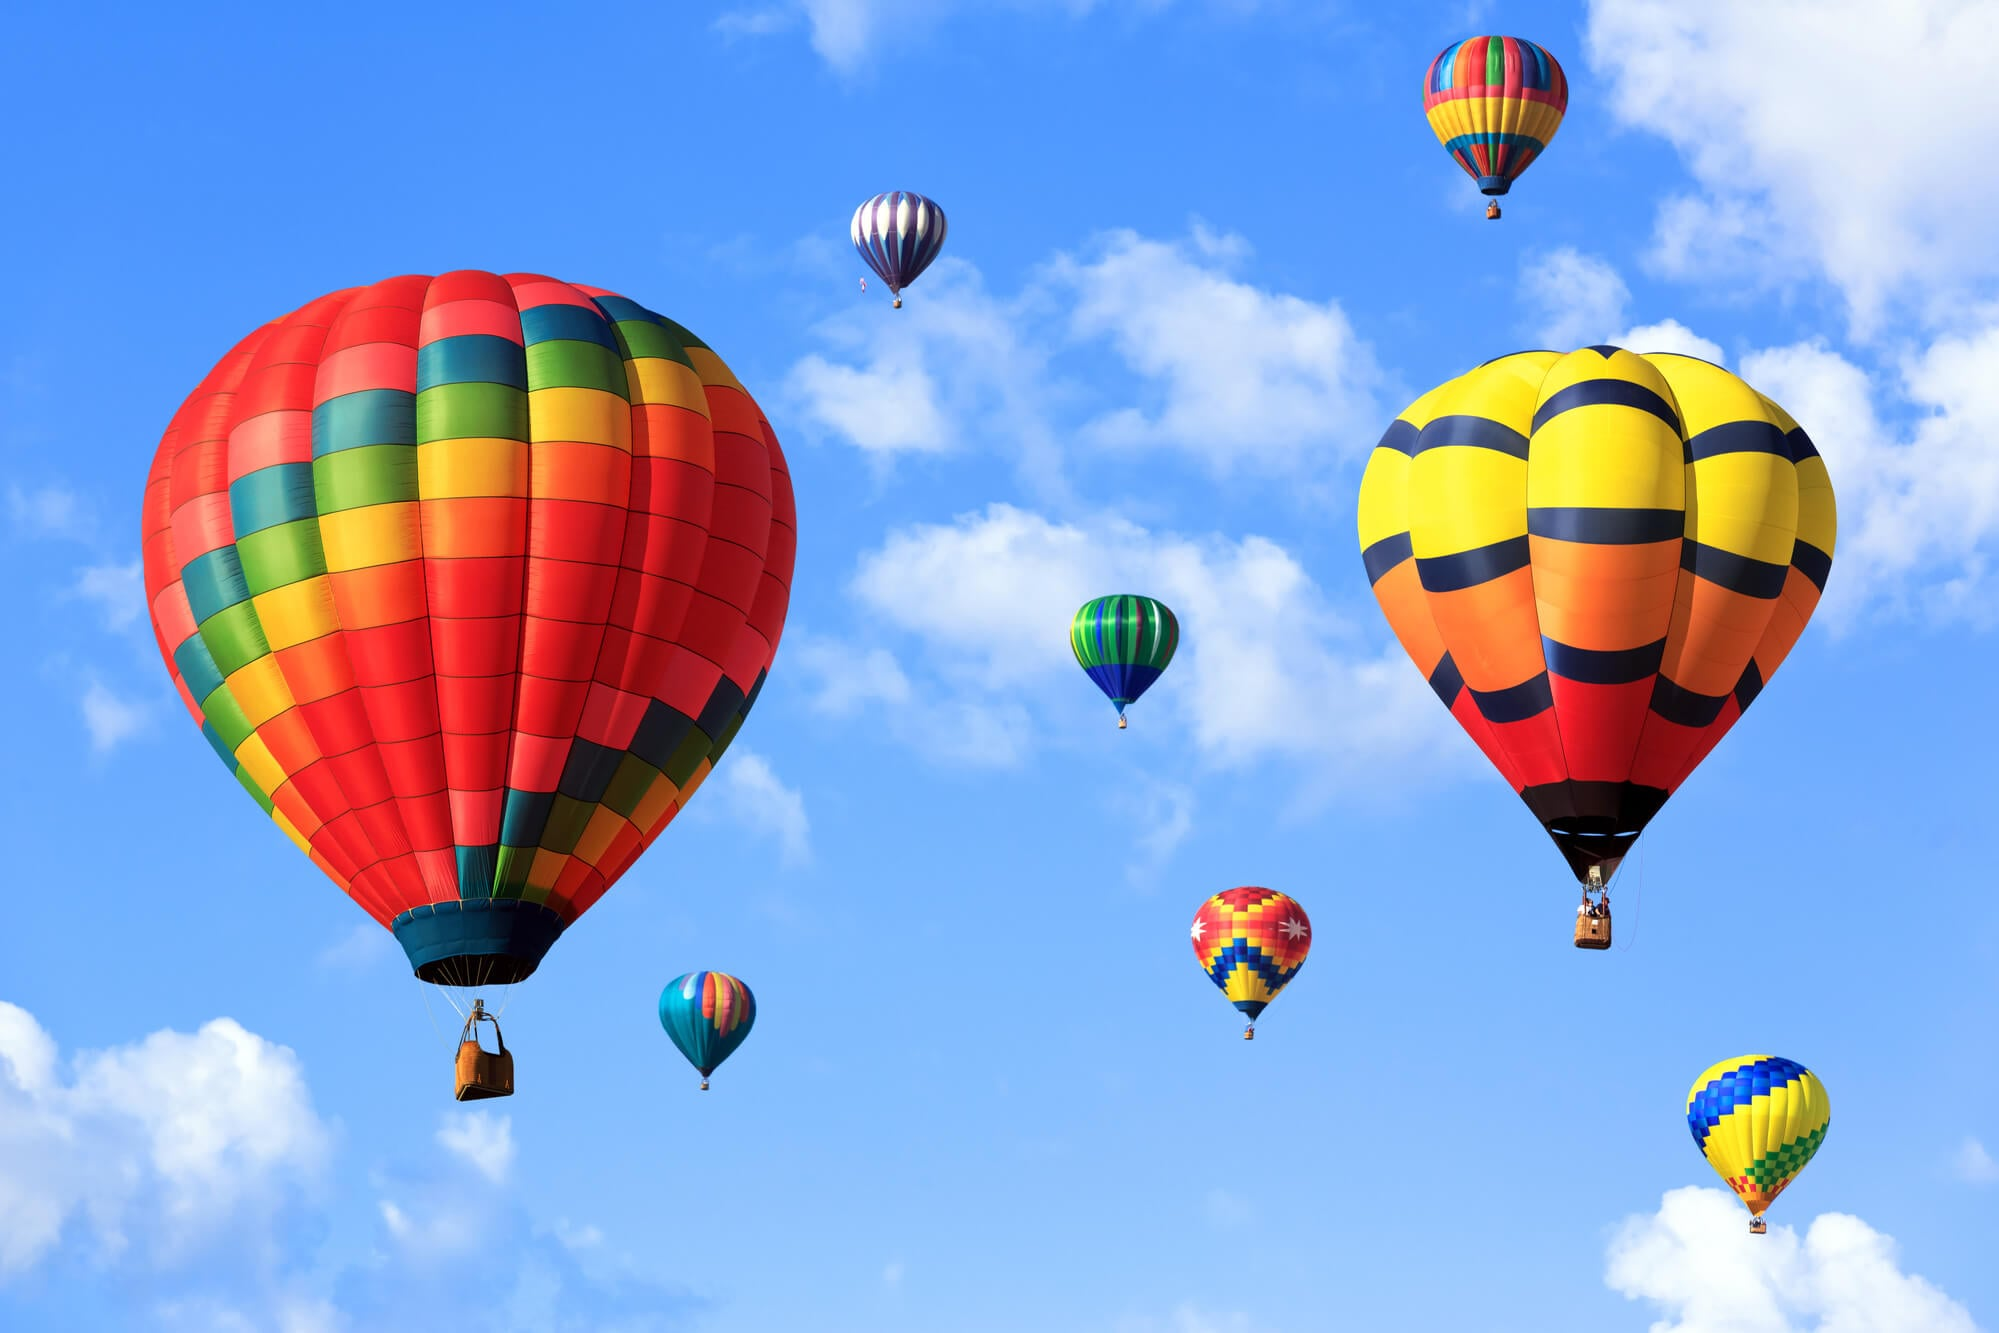

In [6]:
from PIL import Image
import numpy as np
!wget "https://www.daysoftheyear.com/cdn-cgi/image/dpr=1%2Cf=auto%2Cfit=cover%2Ch=1333%2Cq=85%2Cw=1999/wp-content/uploads/hot-air-balloon-day2.jpg"
image = Image.open("hot-air-balloon-day2.jpg")
display(image)

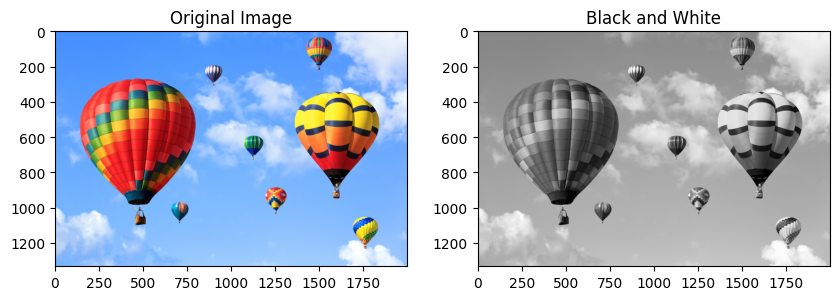

In [7]:
#1. Convert Image to Black and white
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("hot-air-balloon-day2.jpg")
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
bw_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1),plt.imshow(image_rgb),plt.title("Original Image")
plt.subplot(1,2,2),plt.imshow(bw_image,cmap="gray"),plt.title("Black and White")
plt.show()

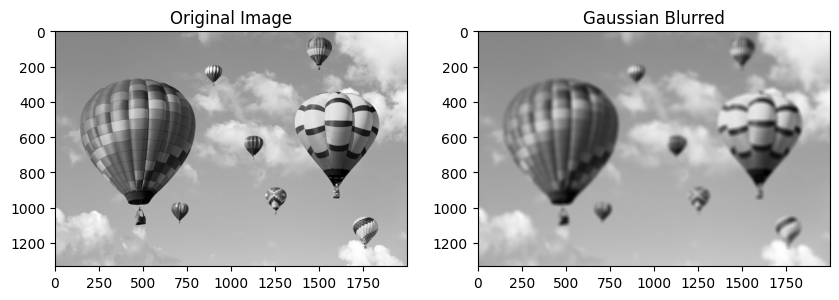

In [8]:
#2. How to use a Gaussian Filter

gaussian_blurred=cv2.GaussianBlur(bw_image,(25, 25), 25)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1),plt.imshow(bw_image,cmap="gray"),plt.title("Original Image")
plt.subplot(1,2,2),plt.imshow(gaussian_blurred,cmap="gray"),plt.title("Gaussian Blurred")
plt.show()

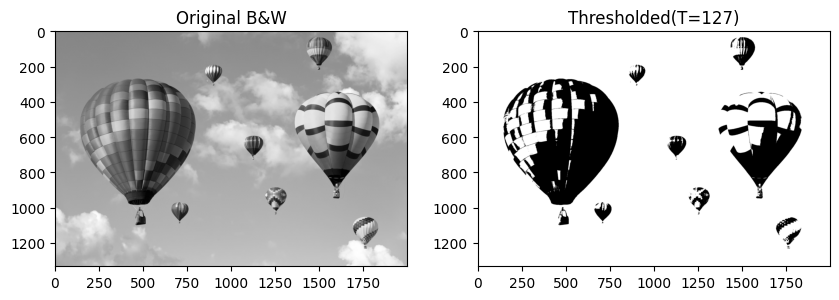

In [9]:
#3. How to use a Thresholding

threshold_value=127
_, thresholded_image=cv2.threshold(bw_image,threshold_value,255,cv2.THRESH_BINARY)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1),plt.imshow(bw_image,cmap="gray"),plt.title("Original B&W")
plt.subplot(1,2,2),plt.imshow(thresholded_image,cmap="gray"),plt.title(f"Thresholded(T={threshold_value})")
plt.show()

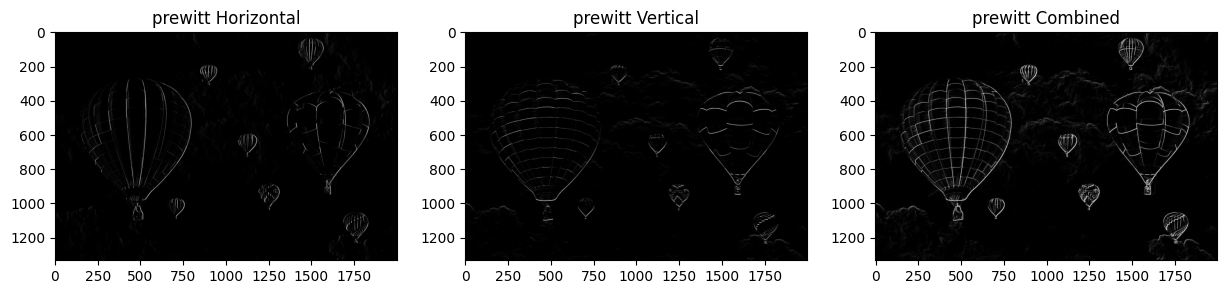

In [10]:
#4. How to use the Prewitt derivative estimate

prewitt_x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

prewitt_x_edges = cv2.filter2D(bw_image, -1, prewitt_x)
prewitt_y_edges = cv2.filter2D(bw_image, -1, prewitt_y)
prewitt_combined = cv2.addWeighted(prewitt_x_edges, 1.5, prewitt_y_edges, 1.5, 0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1),plt.imshow(prewitt_x_edges,cmap="gray"),plt.title("prewitt Horizontal")
plt.subplot(1,3,2),plt.imshow(prewitt_y_edges,cmap="gray"),plt.title("prewitt Vertical")
plt.subplot(1,3,3),plt.imshow(prewitt_combined,cmap="gray"),plt.title("prewitt Combined")
plt.show()
